In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
df.shape

(250000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
objects = df.select_dtypes(include="object")
for i in objects:
    print(f"{i} : {df[i].unique()} --->> {df[i].nunique()}")
    print("=" * 100)

job_title : ['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer'] --->> 12
education_level : ['Bachelor' 'PhD' 'High School' 'Diploma' 'Master'] --->> 5
industry : ['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government'] --->> 10
company_size : ['Medium' 'Small' 'Large' 'Enterprise' 'Startup'] --->> 5
location : ['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK'] --->> 10
remote_work : ['Hybrid' 'No' 'Yes'] --->> 3


In [10]:
df['job_title'].value_counts().sort_values(ascending=False)

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

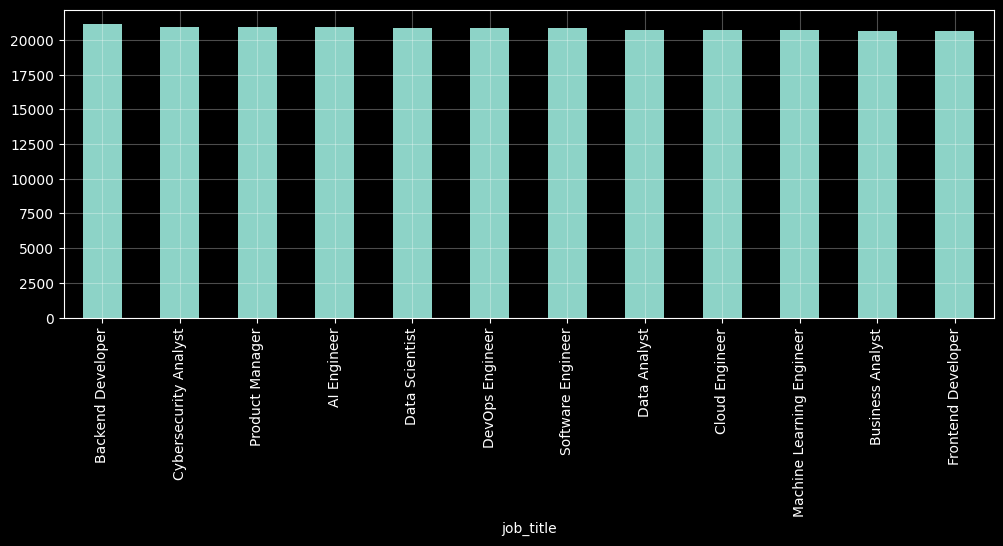

In [11]:
df['job_title'].value_counts().sort_values(ascending=False).plot(kind="bar",figsize=(12,4))
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
df['education_level'].value_counts().sort_values(ascending=False)

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [13]:
df['industry'].value_counts().sort_values(ascending=False)

industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

In [14]:
df['company_size'].value_counts().sort_values(ascending=False)

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [15]:
df['location'].value_counts().sort_values(ascending=False)

location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

In [16]:
df['remote_work'].value_counts().sort_values(ascending=False)

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

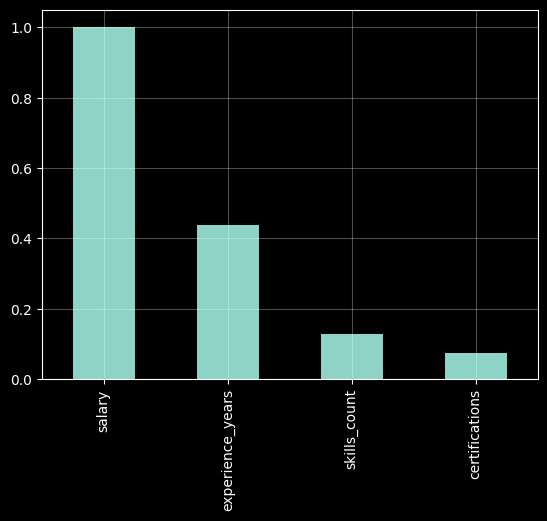

In [17]:
df.corr(numeric_only=True)["salary"].sort_values(ascending=False).plot(kind="bar")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
objects = df.select_dtypes(include="object")
num = df.select_dtypes(exclude="object")

In [19]:
for i in objects:
    print(f"{i} : {df[i].unique()}")

print("=" * 100)
print("=" * 100)

from sklearn.preprocessing import LabelEncoder

la = LabelEncoder()
for i in range(0,objects.shape[1]):
    objects.iloc[:,i] = la.fit_transform(objects.iloc[:,i])
df = pd.concat([objects,num],axis=1)

for i in objects:
    print(f"{i} : {df[i].unique()}")

job_title : ['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']
education_level : ['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']
industry : ['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']
company_size : ['Medium' 'Small' 'Large' 'Enterprise' 'Startup']
location : ['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']
remote_work : ['Hybrid' 'No' 'Yes']
job_title : [0 5 8 2 10 1 9 7 11 4 6 3]
education_level : [0 4 2 1 3]
industry : [4 9 6 7 5 1 2 8 0 3]
company_size : [2 3 1 0 4]
location : [3 0 6 1 7 9 4 5 2 8]
remote_work : [0 1 2]


In [20]:
new_num_data = ["job_title","education_level","industry","company_size","location","remote_work"]
df[new_num_data] = df[new_num_data].astype(int)

### **MODELS**

In [21]:
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error

In [22]:
X = df.drop("salary",axis=1)
y = df['salary']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=44, shuffle =True)

print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (187500, 9)
X_test shape is  (62500, 9)
y_train shape is  (187500,)
y_test shape is  (62500,)


In [24]:
def Models(Model):
    Model.fit(X_train, y_train)
    print(f'Train Score is : {Model.score(X_train, y_train)}')
    print(f'Test Score is : {Model.score(X_test, y_test)}')
    y_pred = Model.predict(X_test)
    print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
    print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
    print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
    print(list(y_test)[:10])
    print(list(y_pred)[:10])
    print('=' * 100)
    print('=' * 100)

In [25]:
LinearRegressionModel = LinearRegression()
Models(LinearRegressionModel)

Train Score is : 0.45844016792296394
Test Score is : 0.4599421117919543
MAE value is  : 21704.09297651435
MSE value is  : 755764151.7457505
MdSE value is  : 17794.147434561375
[195713, 76275, 173874, 151653, 155407, 93579, 174329, 138979, 165867, 76161]
[np.float64(143941.12556122593), np.float64(122449.69550682814), np.float64(156451.18855873434), np.float64(133039.02540743246), np.float64(156092.9511346101), np.float64(109098.60261370422), np.float64(165101.36959192838), np.float64(151121.323215628), np.float64(186947.36999527813), np.float64(84490.55403195453)]


In [26]:
XGBRegressorModel = XGBRegressor(
    n_estimators=800,
    max_depth=6,               
    learning_rate=0.1,
    subsample=0.8,            
    colsample_bytree=0.8,      
    n_jobs=-1,
    random_state=42,
    min_child_weight=3,
    gamma=0.1,
)

Models(XGBRegressorModel)

Train Score is : 0.9832145571708679
Test Score is : 0.9811049699783325
MAE value is  : 4106.4765625
MSE value is  : 26441996.0
MdSE value is  : 3482.08203125
[195713, 76275, 173874, 151653, 155407, 93579, 174329, 138979, 165867, 76161]
[np.float32(196489.33), np.float32(79738.61), np.float32(178146.94), np.float32(151845.62), np.float32(156630.94), np.float32(98991.73), np.float32(168310.06), np.float32(135949.27), np.float32(165375.3), np.float32(81638.55)]


In [27]:
import pickle

with open("Employee_Salary_Prediction.pkl", "wb") as file:
    pickle.dump(XGBRegressorModel, file)